In [2]:
#!python3.12 -m pip install --upgrade --force-reinstall psycopg2

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from datetime import datetime
import itertools
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import psycopg2
import seaborn as sns
import statistics as stats
import math
import sys
sys.path.append(str(Path(f"../../../global_helpers").resolve()))
from generate_httparchive_dates import generate_crawl_identifiers
from plotting_helpers import quick_cdf, print_latex_fig_placeholder

In [5]:
plt.style.use(Path(f"../../../../code/global_helpers/theme_bw.mplstyle").resolve())
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#77AADD", "#99DDFF", "#44BB99", "#BBCC33","#AAAA00","#EEDD88", "#EE8866","#FFAABB", "#DDDDDD"])


In [6]:
img_path = Path(f"../../../../paper/img/httparchive/").resolve()
out_file = Path(f"../../../../data/httparchive/summary/basic_overlap.json").resolve()
with open(out_file) as json_file:
    data = json.load(json_file)


# out_file = Path(f"../../../../data/httparchive/summary/window_overlap.json").resolve()
# with open(out_file) as json_file:
#     window_data = json.load(json_file)
    
   
out_file = Path(f"../../../../data/httparchive/summary/window_overlap_change_counts_new.json").resolve()
with open(out_file) as json_file:
    window_data = json.load(json_file) 


In [7]:
def group_time_delts(months):
    if months == 1:
        return "1 Month"
    elif months <= 6:
        return "2 - 6 Months"
    elif months <=12:
        return "7 Months - 1 Year"
    return "Over 1 Year"

In [8]:
crawl_identifiers = generate_crawl_identifiers()

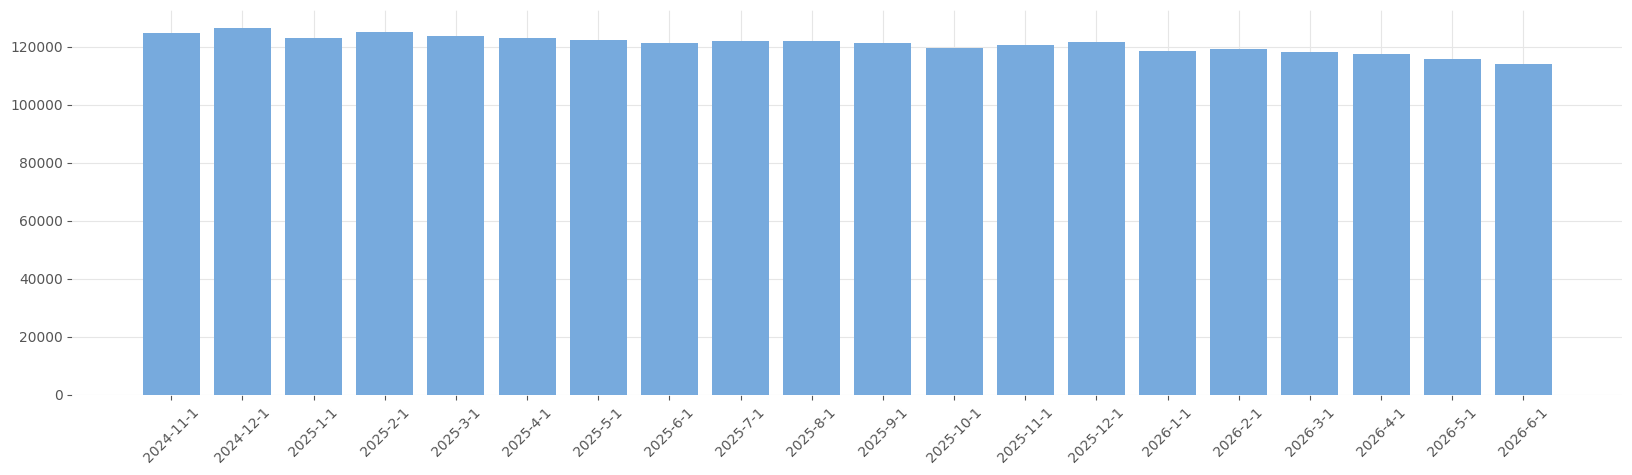

120938.95


In [9]:
plt.figure(figsize=(20, 5))
plt.bar(
    crawl_identifiers,
    [data.get(date, dict()).get("total_pages",0) for date in crawl_identifiers]
)
plt.xticks(rotation=45)
plt.show()

print(stats.mean([data.get(date, dict()).get("total_pages",0) for date in crawl_identifiers]))

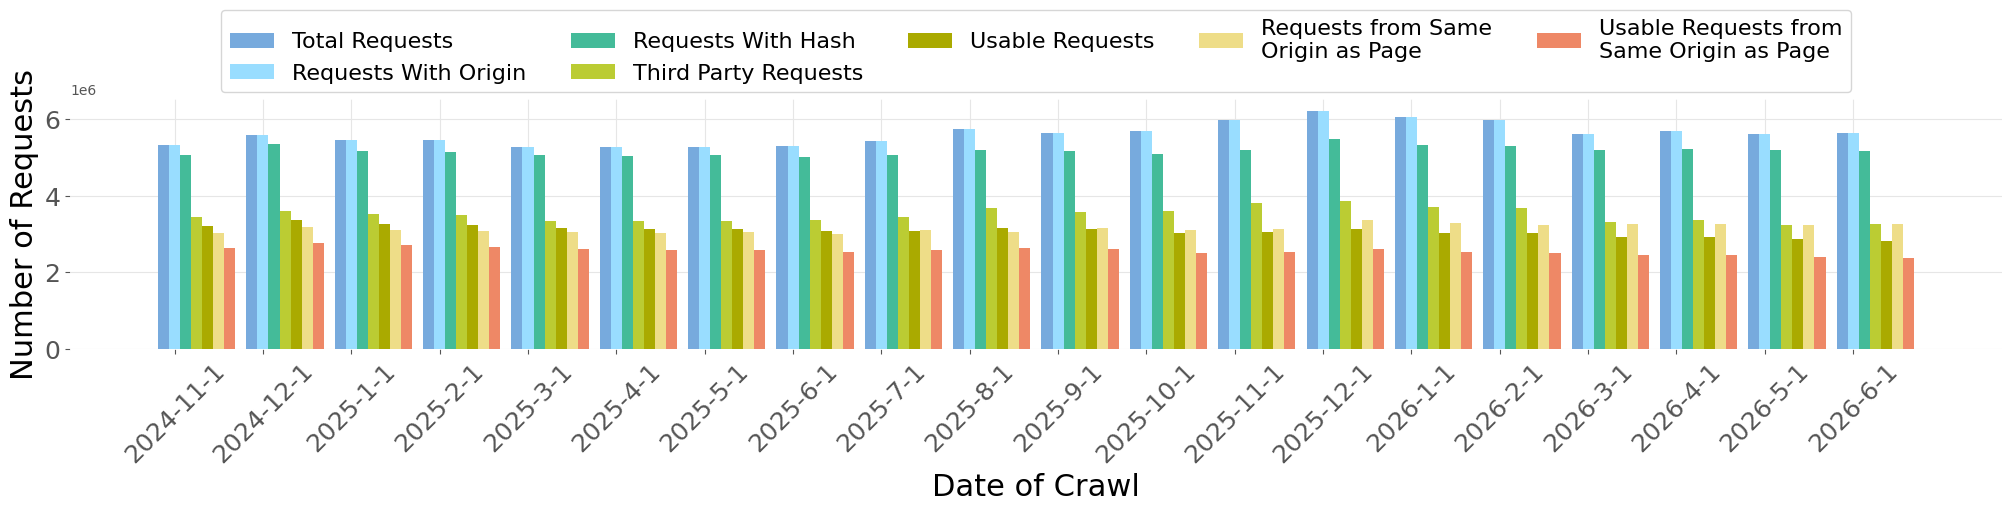

In [10]:
dates = crawl_identifiers
data_means = {
    'Total Requests': [data.get(date, dict()).get("total_requests",0) for date in crawl_identifiers],
    'Requests With Origin': [data.get(date, dict()).get("requests_w_ref_better",0) for date in crawl_identifiers],
    'Requests With Hash': [data.get(date, dict()).get("requests_w_hash",0) for date in crawl_identifiers],
    'Third Party Requests': [data.get(date, dict()).get("requests_3rd_pty",0) for date in crawl_identifiers],
    'Usable Requests': [data.get(date, dict()).get("requests_usable_not_restrict_ref",0) for date in crawl_identifiers],
    'Requests from Same\nOrigin as Page': [data.get(date, dict()).get("requests_not_diff_ref",0) for date in crawl_identifiers],
    'Usable Requests from\nSame Origin as Page': [data.get(date, dict()).get("requests_usable",0) for date in crawl_identifiers],
}

x = np.arange(len(dates))
width = 1.0/(len(data_means)+1)
multiplier = 0


fig, ax = plt.subplots(layout='constrained', figsize=(20, 5))
plt.rcParams.update({'font.size': 14})
for attribute, measurement in data_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    #ax.bar_label(rects, padding=3)
    multiplier += 1

ax.set_xlabel("Date of Crawl", fontsize=22)
ax.set_ylabel("Number of Requests", fontsize=22)

ax.set_xticks(x + width, dates, rotation=45 )

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncols=5, fontsize=16)
plt.savefig(f"{img_path}/requests_summary.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()

In [11]:
# plot page overlap
done = set()
scale=100000
num_months = len(crawl_identifiers)
page_overlap = np.zeros((num_months, num_months))
req_overlap = np.zeros((num_months, num_months))
hash_diff = np.zeros((num_months, num_months))
hash_diff_prop = np.zeros((num_months, num_months))
hash_diff_not_ref_prop = np.zeros((num_months, num_months))

hash_diff_interval_diff = dict()
hash_diff_interval_grouped_diff = dict()
hash_diff_interval_count = dict()
hash_diff_interval_count_rank = dict()
hash_diff_interval_grouped_count = dict()

avg_req_overlap_per_pg = np.zeros((num_months, num_months))
avg_req_overlap_per_pg_not_iframe = np.zeros((num_months, num_months))

for i, date1 in enumerate(crawl_identifiers):
    for j, date2 in enumerate(crawl_identifiers):
        if (i,j) in done or (j,i) in done or date1==date2:
            continue
        d1 = datetime.strptime(date1,"%Y-%m-%d")
        d2 = datetime.strptime(date2,"%Y-%m-%d")
        # Calculate difference
        time_delta = int(round((d2 - d1).days/30, 0))
        grouped_delta = group_time_delts(time_delta)
        
        

        
        overlaping_pages = 0    
        try:
            overlaping_pages = data[date1][date2]["page_overlap"]
        except:
            try: 
                overlaping_pages = data[date2][date1]["page_overlap"]
            except: pass
            
        page_overlap[i][j] = overlaping_pages
        page_overlap[j][i] = overlaping_pages
        
        
        
        overlaping_req = 0       
        req_overlap_hash_diff = 0
        
        
        hash_diff_interval_diff[time_delta] =  hash_diff_interval_diff.get(time_delta, 0)
        hash_diff_interval_grouped_diff[grouped_delta] =  hash_diff_interval_grouped_diff.get(grouped_delta, 0)
        hash_diff_interval_count[time_delta] =  hash_diff_interval_count.get(time_delta, 0)
        hash_diff_interval_grouped_count[grouped_delta] =  hash_diff_interval_grouped_count.get(grouped_delta, 0)
        
        try:
            
            hash_diff_interval_count_rank[time_delta] = hash_diff_interval_count_rank.get(time_delta, dict())
            for r1, r2, diff in  data[date1][date2]["rank_split_hash_diff_not_iframe"]:
                avg_rank = r2#(r1+r2)/2
                hash_diff_interval_count_rank[time_delta][avg_rank] = hash_diff_interval_count_rank[time_delta].get(avg_rank, 0) + diff
            
            overlaping_req = data[date1][date2]["req_overlap"]
            hash_diff_interval_count[time_delta] += data[date1][date2]["req_overlap"]
            hash_diff_interval_grouped_count[grouped_delta] += data[date1][date2]["req_overlap"]
            
            req_overlap_hash_diff = data[date1][date2]["req_overlap_hash_diff"]
            hash_diff_interval_diff[time_delta]+=data[date1][date2]["req_overlap_hash_diff"]
            hash_diff_interval_grouped_diff[grouped_delta]+=data[date1][date2]["req_overlap_hash_diff"]
            
        except:
            try: 
                overlaping_req = data[date2][date1]["req_overlap"]
                hash_diff_interval_count[time_delta] += data[date2][date1]["req_overlap"]
                hash_diff_interval_grouped_count[grouped_delta] += data[date2][date1]["req_overlap"]
            
                req_overlap_hash_diff = data[date2][date1]["req_overlap_hash_diff"]
                hash_diff_interval_diff[time_delta]+=data[date2][date1]["req_overlap_hash_diff"]
                hash_diff_interval_grouped_diff[grouped_delta]+=data[date2][date1]["req_overlap_hash_diff"]
            except: pass
            
        # total requests
        req_overlap[i][j] = overlaping_req
        req_overlap[j][i] = overlaping_req
        
        
       
        # numebr hash different 
        hash_diff[i][j] = req_overlap_hash_diff
        hash_diff[j][i] = req_overlap_hash_diff
        
        # prop diff has out of all
        if not overlaping_req==0:
            hash_diff_prop[i][j] = req_overlap_hash_diff/overlaping_req
            hash_diff_prop[j][i] = req_overlap_hash_diff/overlaping_req
        else:
            hash_diff_prop[i][j] = 0
            hash_diff_prop[j][i] = 0 
          
          
        if data[date1][date2].get("req_overlap_not_iframe",0) == 0:
            hash_diff_not_ref_prop[i][j] = 0
            hash_diff_not_ref_prop[j][i] = 0 
        else:
            hash_diff_not_ref_prop[i][j] = data[date1][date2]["req_overlap_hash_diff_not_iframe"]/data[date1][date2]["req_overlap_not_iframe"]
            hash_diff_not_ref_prop[j][i] = data[date1][date2]["req_overlap_hash_diff_not_iframe"]/data[date1][date2]["req_overlap_not_iframe"]
          
            
        
        avg_req_overlap_per_pg_not_iframe_for_combo = 0   
        try:
            avg_req_overlap_per_pg_for_combo = data[date2][date1]["req_overlap"]/data[date2][date1]["page_overlap"]
            avg_req_overlap_per_pg_not_iframe_for_combo = data[date2][date1]["req_overlap_not_iframe"]/data[date2][date1]["page_overlap"]
        except:
            try: 
                avg_req_overlap_per_pg_for_combo = data[date1][date2]["req_overlap"]/data[date1][date2]["page_overlap"]
                avg_req_overlap_per_pg_not_iframe_for_combo = data[date1][date2]["req_overlap_not_iframe"]/data[date2][date1]["page_overlap"]
                
            except: pass
        avg_req_overlap_per_pg[i][j] = avg_req_overlap_per_pg_for_combo
        avg_req_overlap_per_pg[j][i] = avg_req_overlap_per_pg_for_combo
        
        avg_req_overlap_per_pg_not_iframe[i][j] =avg_req_overlap_per_pg_not_iframe_for_combo
        avg_req_overlap_per_pg_not_iframe[j][i] =avg_req_overlap_per_pg_not_iframe_for_combo
        
        done.add((i, j))
        done.add((j, i))
        
        

        

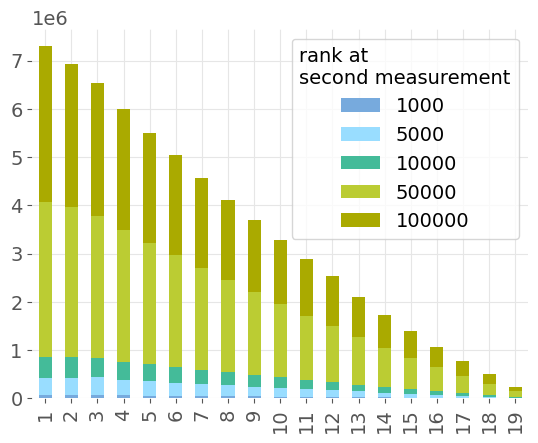

\begin{figure}[tb]
    \centering
    \includegraphics[width=\linewidth]{img/httparchive/hash_diff_interval_count_rank}
    \caption{\todo{hash\_diff\_interval\_count\_rank}.}
    \label{fig:hash_diff_interval_count_rank}
\end{figure}


In [12]:
filename = "hash_diff_interval_count_rank"
df = pd.DataFrame(hash_diff_interval_count_rank)
df.transpose().plot.bar(stacked=True)
plt.savefig(f"{img_path}/{filename}.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.legend(title="rank at\nsecond measurement")
plt.show()
print_latex_fig_placeholder(filename)

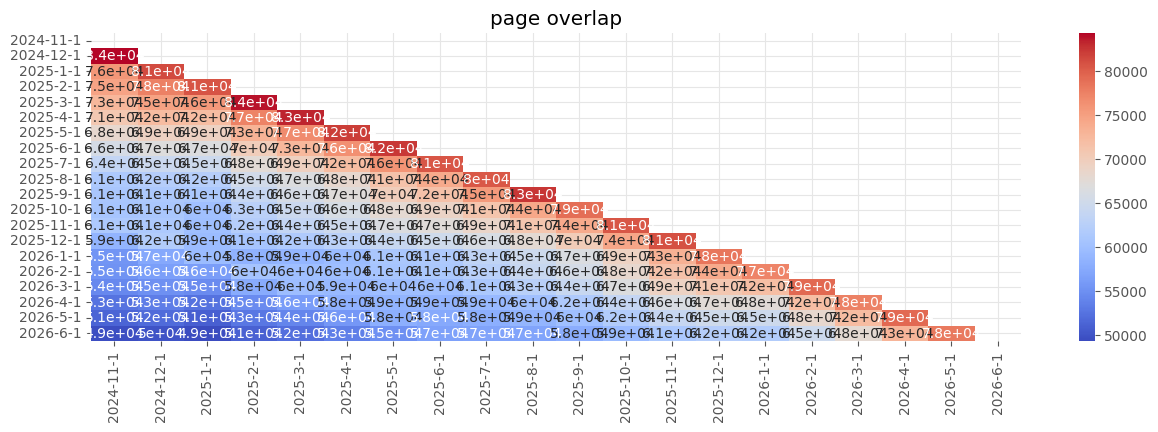

In [13]:
mask = np.zeros_like(page_overlap)      
mask[np.triu_indices_from(mask)] = True  

plt.rcParams.update({'font.size': 10})
plt.figure(figsize=(15, 4))
sns.heatmap(page_overlap, 
            mask=mask, 
            cmap='coolwarm', 
            annot=True, 
            xticklabels=crawl_identifiers, 
            yticklabels=crawl_identifiers)
plt.title("page overlap")
plt.show()       
        

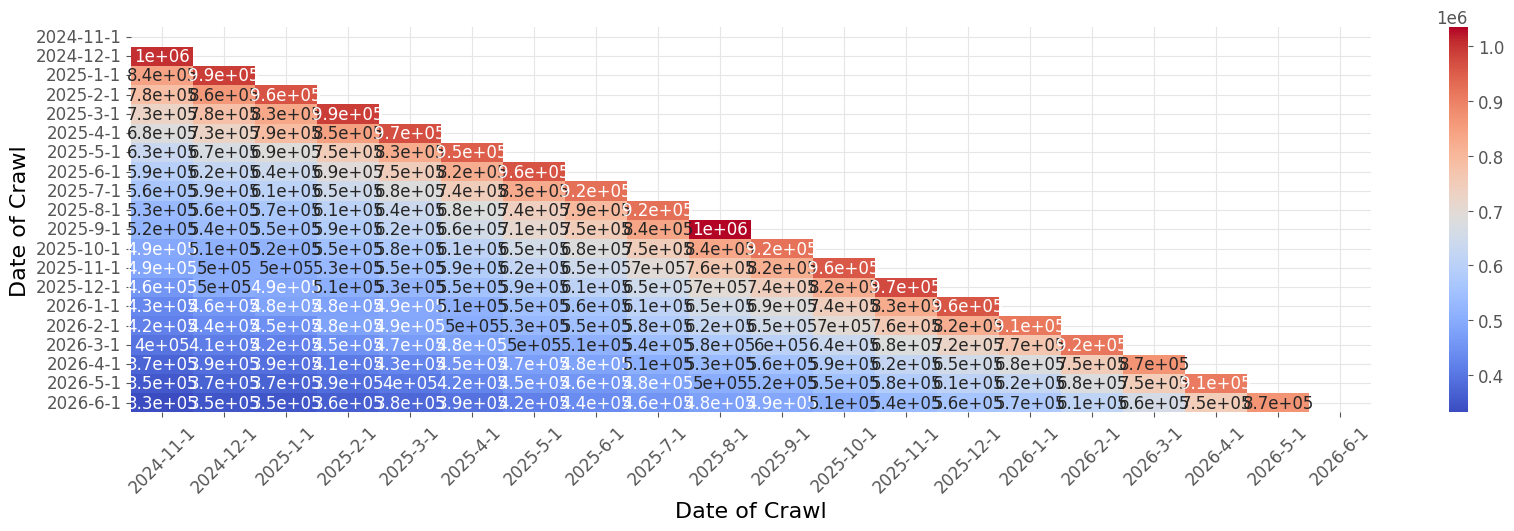

In [14]:

plt.figure(figsize=(20, 5))
plt.rcParams.update({'font.size': 12})
sns.heatmap(req_overlap, 
            mask=mask, 
            cmap='coolwarm', 
            annot=True, 
            xticklabels=crawl_identifiers, 
            yticklabels=crawl_identifiers)
plt.xlabel("Date of Crawl", fontsize=16)
plt.ylabel("Date of Crawl", fontsize=16)
plt.xticks(rotation=45)
plt.show()       

# Hash Changes

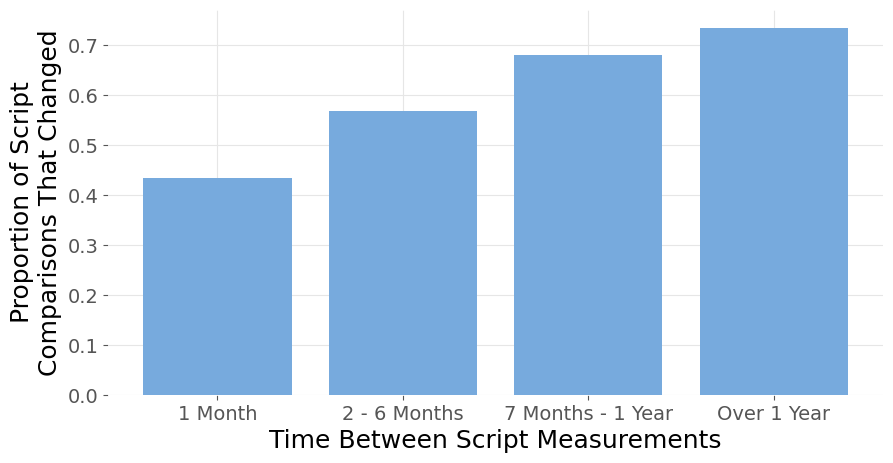

\begin{figure}[tb]
    \centering
    \includegraphics[width=\linewidth]{img/httparchive/hash_diff_interval_grouped}
    \caption{\todo{hash\_diff\_interval\_grouped}.}
    \label{fig:hash_diff_interval_grouped}
\end{figure}


In [15]:
filename = "hash_diff_interval_grouped"
plt.figure(figsize=(10, 5))
sorted_keys = ["1 Month", "2 - 6 Months", "7 Months - 1 Year", "Over 1 Year"]
sorted_values = [hash_diff_interval_grouped_diff[k]/hash_diff_interval_grouped_count[k] for k in sorted_keys]
plt.bar(
    sorted_keys, 
    sorted_values
)
plt.ylabel("Proportion of Script\nComparisons That Changed", fontsize = 18)
plt.xlabel("Time Between Script Measurements", fontsize = 18)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.savefig(f"{img_path}/{filename}.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()
print_latex_fig_placeholder(filename)

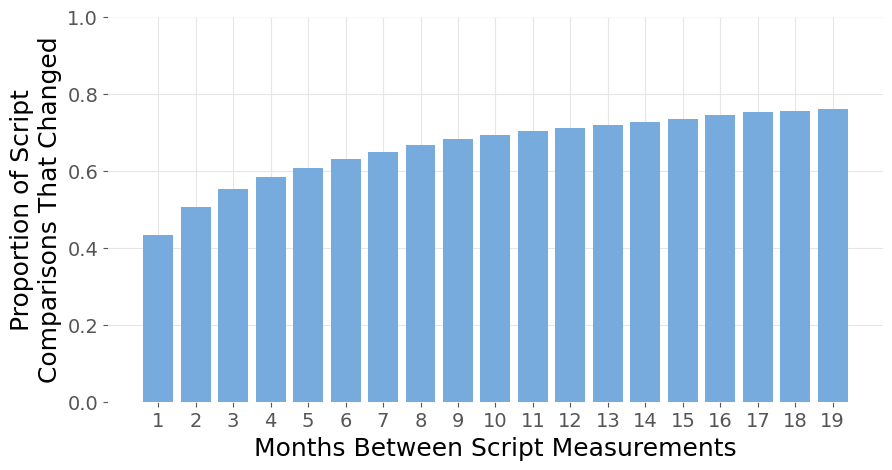

\begin{figure}[tb]
    \centering
    \includegraphics[width=\linewidth]{img/httparchive/hash_diff_interval_diff}
    \caption{\todo{hash\_diff\_interval\_diff}.}
    \label{fig:hash_diff_interval_diff}
\end{figure}


In [16]:
filename = "hash_diff_interval_diff"
plt.figure(figsize=(10, 5))
sorted_keys = list(hash_diff_interval_count.keys())
sorted_values = [hash_diff_interval_diff[k]/hash_diff_interval_count[k] for k in sorted_keys]
plt.bar(
    sorted_keys, 
    sorted_values
)
plt.ylim((0,1))
plt.ylabel("Proportion of Script\nComparisons That Changed", fontsize = 18)
plt.xlabel("Months Between Script Measurements", fontsize = 18)
plt.xticks(sorted_keys, fontsize = 14)
plt.yticks(fontsize = 14)
plt.savefig(f"{img_path}/{filename}.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()
print_latex_fig_placeholder(filename)

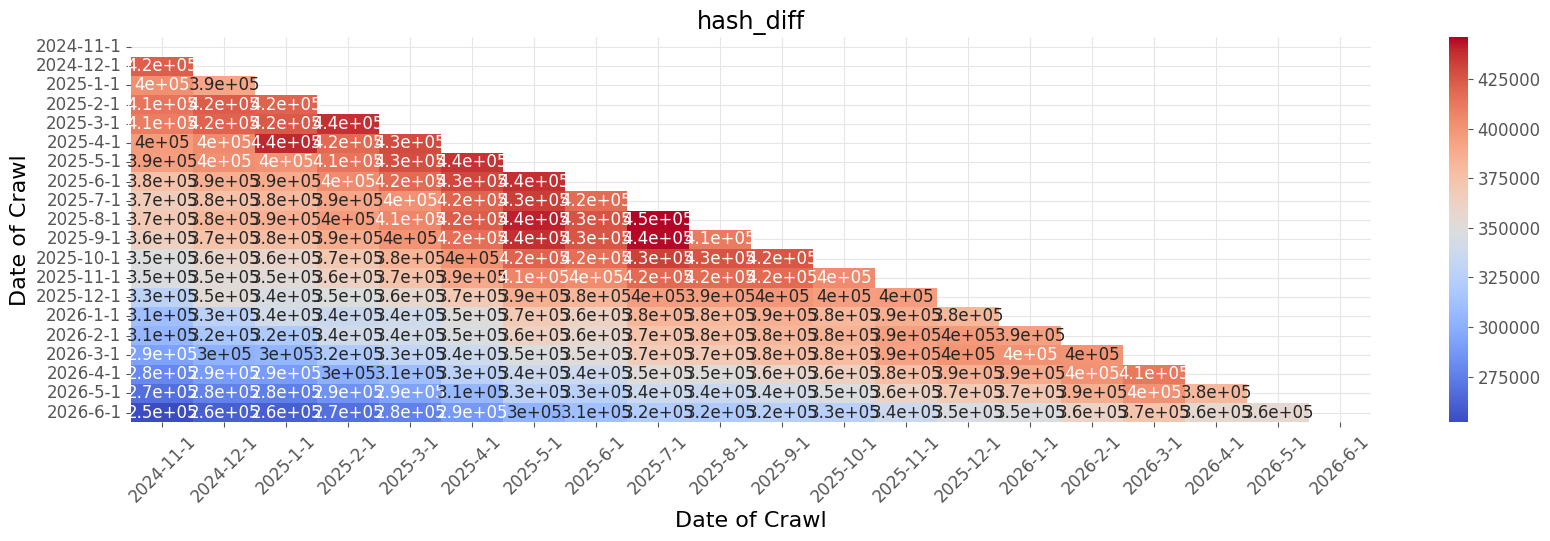

In [17]:

plt.figure(figsize=(20, 5))
plt.rcParams.update({'font.size': 12})
sns.heatmap(hash_diff, 
            mask=mask, 
            cmap='coolwarm', 
            annot=True, 
            xticklabels=crawl_identifiers, 
            yticklabels=crawl_identifiers)
plt.title("hash_diff")
plt.xlabel("Date of Crawl", fontsize=16)
plt.ylabel("Date of Crawl", fontsize=16)
plt.xticks(rotation=45)
plt.show() 

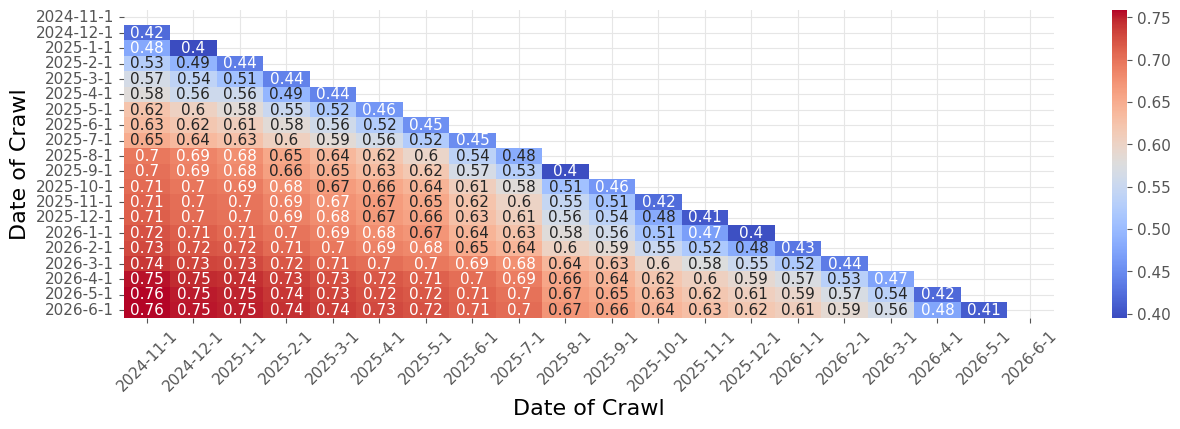

In [18]:

plt.figure(figsize=(15, 4))
plt.rcParams.update({'font.size': 11})
sns.heatmap(hash_diff_prop , 
            mask=mask, 
            cmap='coolwarm', 
            annot=True, 
            xticklabels=crawl_identifiers, 
            yticklabels=crawl_identifiers)
plt.xlabel("Date of Crawl", fontsize=16)
plt.ylabel("Date of Crawl", fontsize=16)
plt.xticks(rotation=45)
plt.savefig(f"{img_path}/prop_hash_diff.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show() 

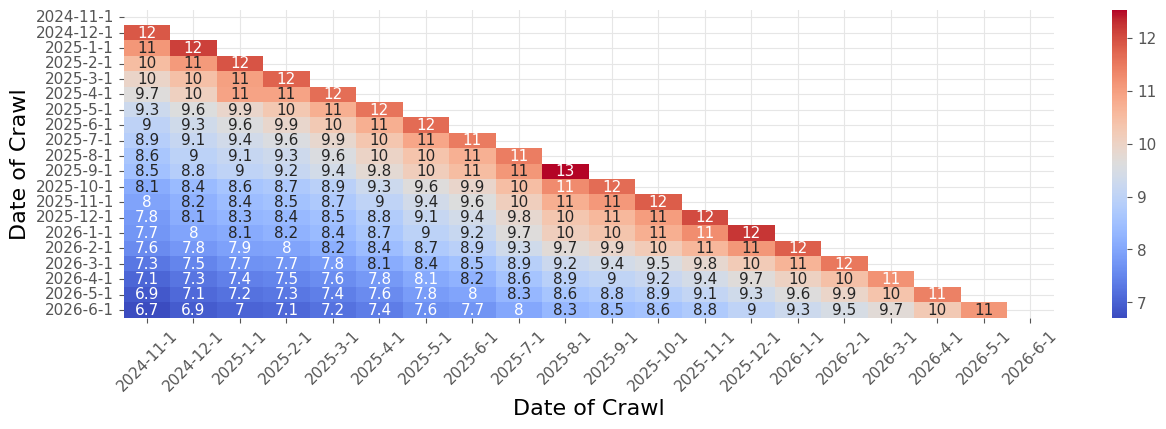

In [19]:
plt.figure(figsize=(15, 4))
plt.rcParams.update({'font.size': 11})
sns.heatmap(avg_req_overlap_per_pg , 
            mask=mask, 
            cmap='coolwarm', 
            annot=True, 
            xticklabels=crawl_identifiers, 
            yticklabels=crawl_identifiers)
plt.xlabel("Date of Crawl", fontsize=16)
plt.ylabel("Date of Crawl", fontsize=16)
plt.xticks(rotation=45)
plt.savefig(f"{img_path}/avg_req_overlap_per_pg.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show() 

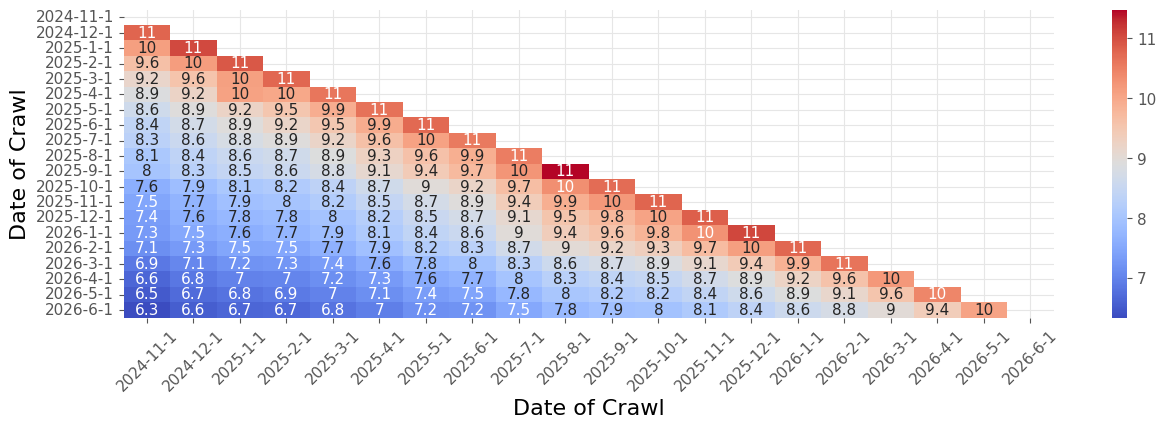

In [20]:
plt.figure(figsize=(15, 4))
plt.rcParams.update({'font.size': 11})
sns.heatmap(avg_req_overlap_per_pg_not_iframe , 
            mask=mask, 
            cmap='coolwarm', 
            annot=True, 
            xticklabels=crawl_identifiers, 
            yticklabels=crawl_identifiers)
plt.xlabel("Date of Crawl", fontsize=16)
plt.ylabel("Date of Crawl", fontsize=16)
plt.xticks(rotation=45)
plt.savefig(f"{img_path}/avg_req_overlap_per_pg_ref_same_as_pg.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show() 

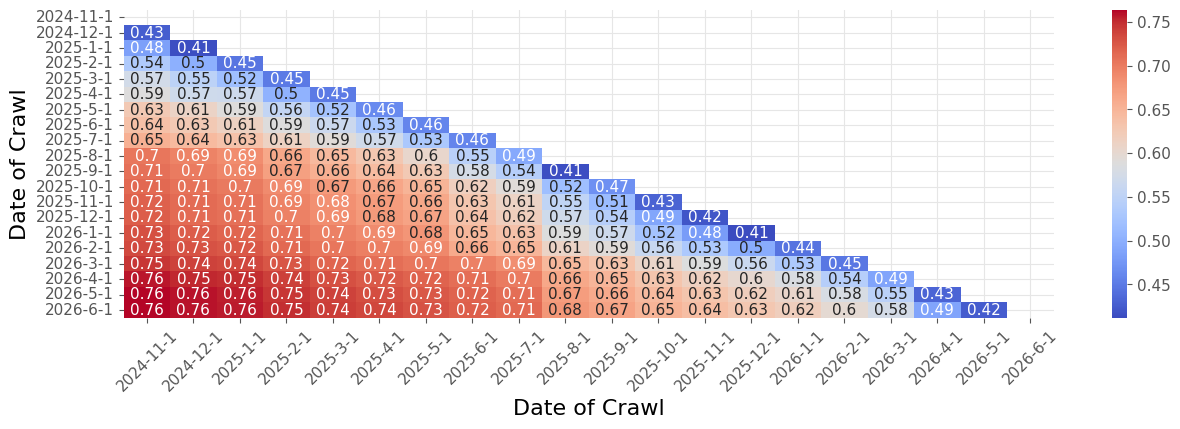

In [21]:

plt.figure(figsize=(15, 4))
plt.rcParams.update({'font.size': 11})
sns.heatmap(hash_diff_not_ref_prop , 
            mask=mask, 
            cmap='coolwarm', 
            annot=True, 
            xticklabels=crawl_identifiers, 
            yticklabels=crawl_identifiers)
plt.xlabel("Date of Crawl", fontsize=16)
plt.ylabel("Date of Crawl", fontsize=16)
plt.xticks(rotation=45)
plt.savefig(f"{img_path}/hash_diff_not_ref_prop.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show() 

# Window

In [22]:
window_data['1'].keys()

# summary[str(time_period)]["len_query"]
# summary[str(time_period)]["all_uniq_comp"]
# summary[str(time_period)]["any_change"]
# summary[str(time_period)]["num_changes_per_script"]
# summary[str(time_period)]["num_event_per_script"]
# summary[str(time_period)]["current_timeperiods"]
# summary[str(time_period)]["current_timeperiods_change"]

dict_keys(['len_query', 'all_uniq_comp', 'any_change', 'num_changes_per_script', 'num_event_per_script'])

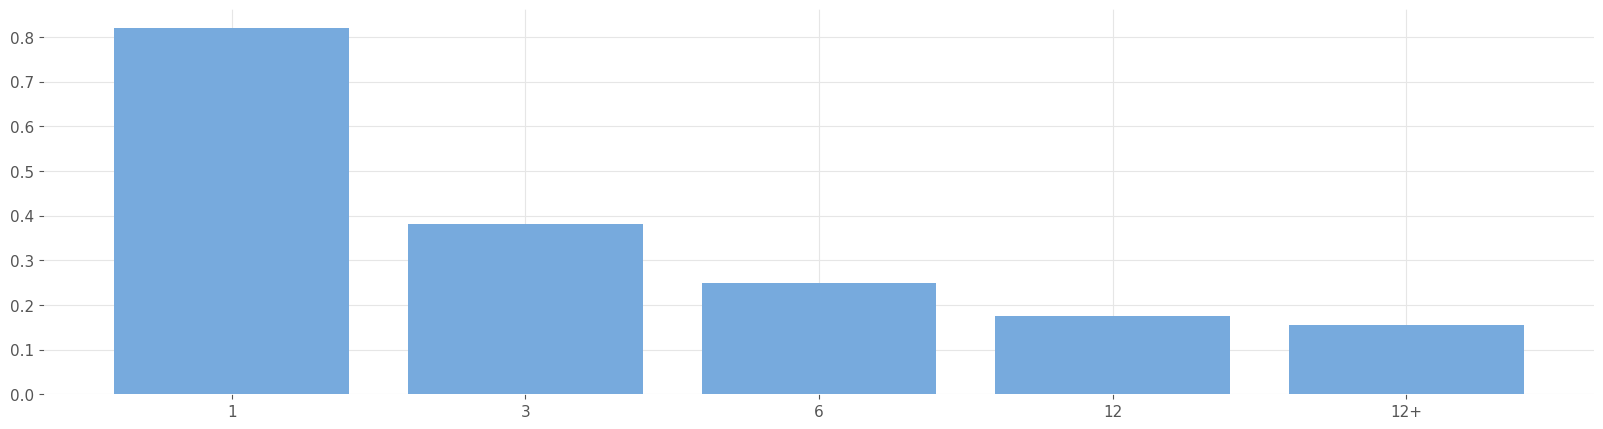

In [23]:
#Bar of uniq script prop
plt.figure(figsize=(20, 5))
plt.bar(
    [k if k != '100' else "12+" for k in window_data.keys()],
    [window_data[window].get("all_uniq_comp",0)/window_data[window].get("len_query",0) for window in window_data.keys()]
)
plt.xticks()
plt.show()

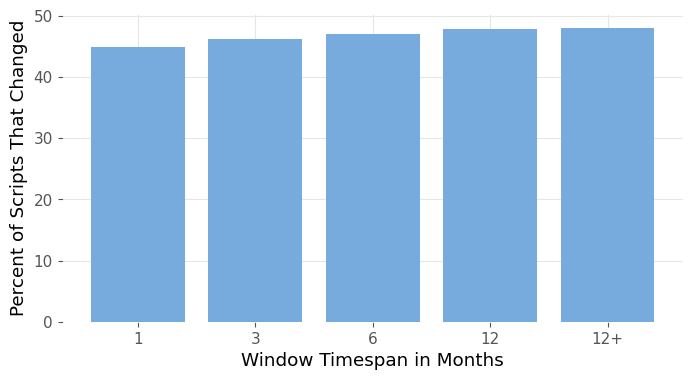

In [24]:
#Hist of proportion with hash change
plt.figure(figsize=(8, 4))
plt.bar(
    [k if k != '100' else "12+" for k in window_data.keys()],
    [window_data[window].get("any_change",0)/window_data[window].get("all_uniq_comp",0)*100 for window in window_data.keys()]
)
plt.ylabel("Percent of Scripts That Changed")
plt.xlabel("Window Timespan in Months")
plt.savefig(f"{img_path}/hash_diff_window.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()

In [25]:
# 

# summary[str(time_period)]["current_timeperiods"]
# summary[str(time_period)]["current_timeperiods_change"]

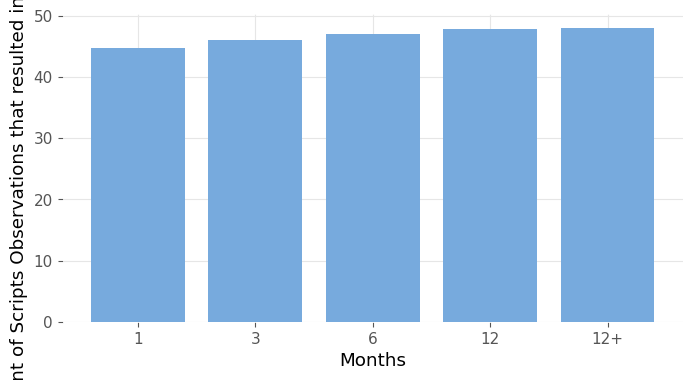

In [26]:
#Hist of proportion with hash change
plt.figure(figsize=(8, 4))
plt.bar(
    [k if k != '100' else "12+" for k in window_data.keys()],
    [stats.mean([x/y for x, y in zip(window_data[window]["num_changes_per_script"],window_data[window]["num_event_per_script"])])*100 for window in window_data.keys()]
)
plt.ylabel("Percent of Scripts Observations that resulted in a change")
plt.xlabel("Months")
plt.savefig(f"{img_path}/hash_diff_window.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()

In [27]:
window_data['100'].keys()

dict_keys(['len_query', 'all_uniq_comp', 'any_change', 'num_changes_per_script', 'num_event_per_script', 'current_timeperiods', 'current_timeperiods_change'])

In [28]:
#num crawls scripts appear in 
a = [len(x) for x in window_data['100']["current_timeperiods"]]
print(print(pd.Series(a).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])))

count    3.333033e+06
mean     5.497466e+00
std      5.494971e+00
min      1.000000e+00
10%      1.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      8.000000e+00
90%      1.600000e+01
max      1.700000e+01
dtype: float64
None


In [29]:
#num changes for scripts that change once
a = [len(x) for x in filter(lambda b: len(b)>0, window_data['100']["current_timeperiods_change"])]
print(print(pd.Series(a).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])))

count    1.598206e+06
mean     7.173906e+00
std      5.936308e+00
min      1.000000e+00
10%      1.000000e+00
25%      2.000000e+00
50%      5.000000e+00
75%      1.300000e+01
90%      1.700000e+01
max      1.700000e+01
dtype: float64
None


In [30]:
#num changes for all scripts 
a = [len(x) for x in window_data['100']["current_timeperiods_change"]]
print(print(pd.Series(a).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])))

count    3.333033e+06
mean     3.439924e+00
std      5.453646e+00
min      0.000000e+00
10%      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+00
90%      1.400000e+01
max      1.700000e+01
dtype: float64
None


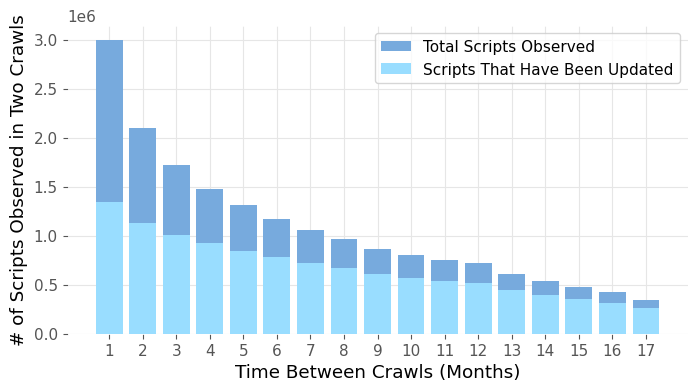

In [31]:
plt.figure(figsize=(8, 4))
interval_counts = dict()
interval_changes = dict()

for all_timeperiods,change_timeperiods in zip(window_data['100']["current_timeperiods"], window_data['100']["current_timeperiods_change"]):
    #print(all_timeperiods,change_timeperiods)
    for x in all_timeperiods:
        interval_counts[x] = interval_counts.get(x,0)+1
    for x in change_timeperiods:
        interval_changes[x] = interval_changes.get(x,0)+1
  
categories, values = zip(*interval_counts.items())
plt.bar(categories, values, label="Total Scripts Observed")
categories, values = zip(*interval_changes.items())
plt.bar(categories, values, label="Scripts That Have Been Updated")
plt.ylabel("# of Scripts Observed in Two Crawls")
plt.xlabel("Time Between Crawls (Months)")
plt.xticks(range(math.floor(min(categories)), math.ceil(max(categories)) + 1))
plt.legend(loc="upper right")
plt.savefig(f"{img_path}/hash_diff_window_out_of_total.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()



In [32]:
interval_counts = dict()
interval_changes = dict()
interval_changes_nothing_before = dict()

for all_timeperiods,change_timeperiods in zip(window_data['100']["current_timeperiods"], window_data['100']["current_timeperiods_change"]):
    #print(all_timeperiods,change_timeperiods)
    for x in all_timeperiods:
        interval_counts[x] = interval_counts.get(x,0)+1
    for x in change_timeperiods:
        interval_changes[x] = interval_changes.get(x,0)+1
    
    if change_timeperiods:
        interval_changes_nothing_before[min(change_timeperiods)] = interval_changes_nothing_before.get(min(change_timeperiods),0)+1
    


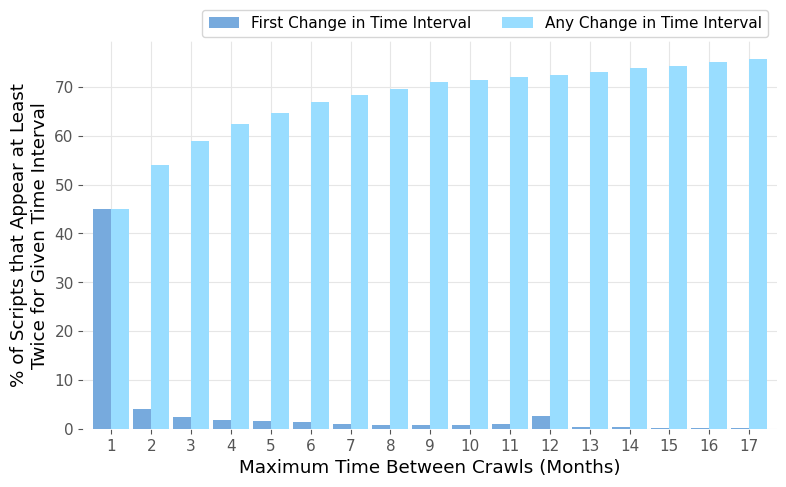

In [33]:

months = interval_counts.keys()
funnel_data = {
    'First Change in Time Interval': [interval_changes_nothing_before[m]/interval_counts[m]*100 for m in months],
    'Any Change in Time Interval': [interval_changes[m]/interval_counts[m]*100 for m in months],
}

df = pd.DataFrame(funnel_data, index=months)
df.plot(kind="bar", figsize=(8, 5), width=.9)


plt.xlabel("Maximum Time Between Crawls (Months)")
plt.ylabel("% of Scripts that Appear at Least\nTwice for Given Time Interval")
plt.xticks(rotation=0)
plt.legend(ncols=2, bbox_to_anchor=(0.998, 1.1))
plt.tight_layout()
plt.savefig(f"{img_path}/hash_diff_window_and_new_for_window.pdf",bbox_inches="tight", format='pdf', dpi=1200)
plt.show()

In [34]:

window_data['100'].keys()


dict_keys(['len_query', 'all_uniq_comp', 'any_change', 'num_changes_per_script', 'num_event_per_script', 'current_timeperiods', 'current_timeperiods_change'])

In [36]:
46539325/2188971

21.260823007705447

In [37]:
88789.2/121610

0.7301142998108708